# Proyecto Big Data — ICFES Saber 11 · v2 (DataIcfes)
## Pontificia Universidad Javeriana — Ingeniería de Sistemas
**Docente:** John Corredor, PhD  
**Equipo:** Juan Martin Trejos · Juan Santiago Mendez · Diego Zabala · Juan David Ordoñez  
**Fecha:** 2026  

---
### Hipótesis a verificar
> *El techo de F1 macro ~0.46 del Proyecto v1 se debía a la limitada información de `kgxf-xxbe` (datos.gov.co), no al algoritmo ni al volumen de datos. Con los microdatos completos de DataIcfes (~30 variables adicionales por estudiante), el modelo debería superar ese techo.*

### Diferencias clave v1 → v2
| Aspecto | v1 (kgxf-xxbe) | v2 (DataIcfes) |
|---|---|---|
| Variables por estudiante | ~11 | ~28 |
| NSE individual | Join proxy SISBEN |  `estu_inse_individual` continuo |
| Capital cultural hogar |  No disponible |  `fami_numlibros` |
| Tipo colegio | Solo oficial/no oficial | + `cole_caracter`, `cole_jornada` |
| Bienes del hogar | Solo internet+computador | + automóvil, lavadora, TV, moto |
| Hábitos estudiante |  No disponible |  dedicación internet, lectura diaria |
| Situación laboral |  No disponible |  horas trabajo, trabajo padres |


In [37]:
import pandas as pd
from pathlib import Path

# Revisar un archivo de cada año para ver el nombre exacto de la columna
for ruta in sorted(Path("/content/sample_data/Boyaca").glob("Examen_Saber_11_*.txt"))[:4]:
    df_tmp = pd.read_csv(ruta, sep=';', encoding='latin-1', nrows=1)
    cols_caracter = [c for c in df_tmp.columns if 'caract' in c.lower()]
    print(f"{ruta.name}: {cols_caracter}")

Examen_Saber_11_20101.txt: ['cole_caracter']
Examen_Saber_11_20102.txt: ['cole_caracter']
Examen_Saber_11_20111.txt: ['cole_caracter']
Examen_Saber_11_20112.txt: ['cole_caracter']


In [38]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.03, 0.05, 0.08],
    'num_leaves': [31, 50, 70],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.7, 0.8, 0.9],
}
lgbm_search = RandomizedSearchCV(
    LGBMClassifier(class_weight='balanced', random_state=42, verbosity=-1),
    params, n_iter=30, cv=3, scoring='f1_macro',
    random_state=42, n_jobs=-1
)
lgbm_search.fit(X_train, y_train)
print(lgbm_search.best_params_)

{'subsample': 0.9, 'num_leaves': 50, 'n_estimators': 800, 'min_child_samples': 10, 'learning_rate': 0.08}


In [39]:
for ruta in sorted(Path("/content/sample_data/Boyaca").glob("Examen_Saber_11_*.txt")):
    anio = ruta.name[16:20]
    df_tmp = pd.read_csv(ruta, sep=';', encoding='latin-1',
                         usecols=['cole_caracter', 'cole_cod_mcpio_ubicacion'],
                         low_memory=False)
    df_mun = df_tmp[df_tmp['cole_cod_mcpio_ubicacion'] == 15759]
    vals = df_mun['cole_caracter'].dropna().unique()
    pct_nulo = df_mun['cole_caracter'].isnull().mean() * 100
    print(f"{anio}: {pct_nulo:.0f}% nulos | valores únicos: {vals[:5]}")

2010: 0% nulos | valores únicos: ['TÃ\x89CNICO/ACADÃ\x89MICO' 'NO APLICA' 'ACADÃ\x89MICO']
2010: 0% nulos | valores únicos: ['TÃ\x89CNICO/ACADÃ\x89MICO' 'ACADÃ\x89MICO' 'NO APLICA' 'TÃ\x89CNICO']
2011: 0% nulos | valores únicos: ['ACADÃ\x89MICO' 'TÃ\x89CNICO/ACADÃ\x89MICO']
2011: 0% nulos | valores únicos: ['TÃ\x89CNICO/ACADÃ\x89MICO' 'ACADÃ\x89MICO' 'TÃ\x89CNICO' 'NO APLICA']
2012: 0% nulos | valores únicos: ['ACADÃ\x89MICO' 'TÃ\x89CNICO/ACADÃ\x89MICO']
2012: 0% nulos | valores únicos: ['TÃ\x89CNICO/ACADÃ\x89MICO' 'ACADÃ\x89MICO' 'TÃ\x89CNICO' 'NO APLICA']
2013: 0% nulos | valores únicos: ['ACADÃ\x89MICO' 'TÃ\x89CNICO/ACADÃ\x89MICO']
2013: 0% nulos | valores únicos: ['TÃ\x89CNICO/ACADÃ\x89MICO' 'ACADÃ\x89MICO' 'TÃ\x89CNICO']
2014: 0% nulos | valores únicos: ['ACADÃ\x89MICO']
2014: 0% nulos | valores únicos: ['TÃ\x89CNICO/ACADÃ\x89MICO' 'ACADÃ\x89MICO' 'NO APLICA' 'TÃ\x89CNICO']
2015: 0% nulos | valores únicos: ['TÃ\x89CNICO/ACADÃ\x89MICO' 'ACADÃ\x89MICO']
2015: 0% nulos | valores únic

---
## SECCIÓN 0 — Setup global

In [9]:
# Celda 0.1 — Importaciones globales
# Si se necesita una librería nueva, añadirla AQUÍ antes de usarla
import os, re, warnings
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score,
    roc_auc_score, roc_curve, precision_recall_curve
)
from sklearn.neural_network  import MLPClassifier
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# ── Constantes del proyecto ─────────────────────────────────────────
MUNICIPIOS    = {15759: 'Sogamoso', 41551: 'Pitalito'}
ANIOS_TRAIN   = [2015, 2016, 2017, 2019]   # años limpios pre-test
ANIO_TEST     = 2022
CLASES        = {0: 'Bajo', 1: 'Medio', 2: 'Alto'}
TARGET_COL    = 'categoria_punt'
LABELS        = ['Bajo', 'Medio', 'Alto']

# Métricas v1 para comparar hipótesis (actualizar con valores reales)
V1_F1_MACRO   = 0.462   # mejor F1 macro obtenido en v1
V1_ACCURACY   = 0.467   # mejor accuracy obtenido en v1
V1_MODELO     = 'RF tuning | Completo'

print(f"Setup OK — pandas {pd.__version__} | numpy {np.__version__}")


Setup OK — pandas 2.2.2 | numpy 2.0.2


In [10]:
# Pega esto en una celda nueva para diagnosticar qué tienes
for ruta in [HUILA_PATH, BOYACA_PATH]:
    print(f"\n=== {ruta} ===")
    archivos_ruta = sorted(ruta.rglob("Examen_Saber_11_*.txt"))
    print(f"  Archivos encontrados: {len(archivos_ruta)}")
    for f in archivos_ruta[:3]:  # solo los primeros 3
        # ver qué departamentos hay
        import pandas as pd
        df_tmp = pd.read_csv(f, sep=';', encoding='latin-1',
                             usecols=['cole_cod_depto_ubicacion'], nrows=5)
        deptos = df_tmp['cole_cod_depto_ubicacion'].unique().tolist()
        print(f"    {f.name} → deptos: {deptos}")


=== /content/sample_data/Huila ===
  Archivos encontrados: 32
    Examen_Saber_11_20101.txt → deptos: [41]
    Examen_Saber_11_20102.txt → deptos: [41]
    Examen_Saber_11_20111.txt → deptos: [41]

=== /content/sample_data/Boyaca ===
  Archivos encontrados: 32
    Examen_Saber_11_20101.txt → deptos: [15]
    Examen_Saber_11_20102.txt → deptos: [15]
    Examen_Saber_11_20111.txt → deptos: [15]


In [11]:
from pathlib import Path

HUILA_PATH  = Path(r"/content/sample_data/Huila")
BOYACA_PATH = Path(r"/content/sample_data/Boyaca")

archivos = []
for ruta in [HUILA_PATH, BOYACA_PATH]:
    if ruta.exists():
        encontrados = sorted(ruta.rglob("Examen_Saber_11_*.txt"))
        print(f"  {ruta.name}: {len(encontrados)} archivo(s)")
        archivos.extend(encontrados)
    else:
        print(f"  ADVERTENCIA: ruta no existe → {ruta}")

print(f"\nTotal archivos a cargar: {len(archivos)}")
# Debería decir 64 archivos en total

  Huila: 32 archivo(s)
  Boyaca: 32 archivo(s)

Total archivos a cargar: 64


---
## SECCIÓN 1 — Carga de datos DataIcfes

In [12]:
# Celda 1.1 — Columnas a cargar
#
# 28 variables seleccionadas vs ~11 del v1
# Nuevas marcadas con # NUEVO

COLS_CARGAR = [
    'periodo',
    'cole_cod_mcpio_ubicacion',
    'cole_cod_dane_establecimiento',
    # Características del colegio
    'cole_area_ubicacion',
    'cole_naturaleza',
    'cole_caracter',              # NUEVO: académico / técnico
    'cole_jornada',               # NUEVO: mañana / tarde / completa / nocturna
    'cole_bilingue',
    'cole_genero',
    # Características del hogar
    'fami_estratovivienda',
    'fami_educacionmadre',
    'fami_educacionpadre',
    'fami_tieneinternet',
    'fami_tienecomputador',
    'fami_tieneautomovil',        # NUEVO
    'fami_tienelavadora',         # NUEVO
    'fami_tieneserviciotv',       # NUEVO
    'fami_tienemotocicleta',      # NUEVO: proxy socioeconómico rural
    'fami_tienehornomicroogas',   # NUEVO: condiciones del hogar
    'fami_cuartoshogar',          # NUEVO: hacinamiento
    'fami_numlibros',             # NUEVO: capital cultural
    'fami_situacioneconomica',    # NUEVO: percepción económica del hogar
    'fami_personashogar',
    # Características del estudiante
    'estu_genero',                # NUEVO
    'estu_inse_individual',       # NUEVO: índice NSE continuo (reemplaza join SISBEN)
    'estu_nse_establecimiento',   # NUEVO: NSE promedio del colegio (1-4)
    'estu_dedicacioninternet',    # NUEVO: horas semanales en internet
    'estu_dedicacionlecturadiaria', # NUEVO: hábito lector
    'estu_horassemanatrabaja',    # NUEVO: si trabaja y cuántas horas
    'estu_repite',
    # Target
    'punt_global',
]

print(f"Columnas a cargar: {len(COLS_CARGAR)}")
print(f"Variables nuevas vs v1: {len(COLS_CARGAR) - 11}")


Columnas a cargar: 31
Variables nuevas vs v1: 20


In [13]:
# Celda 1.2 — Función de carga

def cargar_archivo(ruta, municipios, cols):
    """Carga un .txt DataIcfes filtrando por municipios."""
    try:
        df = pd.read_csv(
            ruta, sep=';', encoding='latin-1',
            low_memory=False,
            usecols=lambda c: c.lower() in [x.lower() for x in cols]
        )
        df.columns = df.columns.str.lower().str.strip()
        # Asegurar todas las columnas aunque no estén en el archivo
        for col in [c.lower() for c in cols]:
            if col not in df.columns:
                df[col] = np.nan
        df = df[df['cole_cod_mcpio_ubicacion'].isin(municipios)].copy()
        return df
    except Exception as e:
        print(f"  ERROR en {Path(ruta).name}: {e}")
        return pd.DataFrame()


def extraer_anio(nombre_archivo):
    """Extrae el año de 'Examen_Saber_11_20221.txt' → 2022"""
    m = re.search(r'(\d{4})\d\.txt', nombre_archivo, re.IGNORECASE)
    return int(m.group(1)) if m else None


print("Funciones de carga definidas.")


Funciones de carga definidas.


In [14]:
# Celda 1.3 — Carga de todos los archivos

ANIOS_NECESARIOS = ANIOS_TRAIN + [ANIO_TEST]
# ← Ya NO redefinir archivos aquí, viene de la Celda 0.2

frames   = []
resumen  = []

for ruta in archivos:
    anio = extraer_anio(ruta.name)
    if anio not in ANIOS_NECESARIOS:
        continue

    df_tmp = cargar_archivo(ruta, list(MUNICIPIOS.keys()), COLS_CARGAR)
    if len(df_tmp) == 0:
        print(f"  {ruta.name}: sin registros para los municipios — omitido")
        continue

    df_tmp['anio'] = anio
    frames.append(df_tmp)

    n_sog = (df_tmp['cole_cod_mcpio_ubicacion'] == 15759).sum()
    n_pit = (df_tmp['cole_cod_mcpio_ubicacion'] == 41551).sum()
    resumen.append({'Archivo': ruta.name, 'Año': anio,
                    'Sogamoso': n_sog, 'Pitalito': n_pit,
                    'Total': len(df_tmp)})
    print(f"  {ruta.name} → {len(df_tmp):,} filas  "
          f"(Sogamoso: {n_sog:,} | Pitalito: {n_pit:,})")

df_raw = pd.concat(frames, ignore_index=True)

print(f"\nDataset combinado: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
print(f"Años cargados    : {sorted(df_raw['anio'].unique())}")
print(f"\nResumen por archivo:")
display(pd.DataFrame(resumen).set_index('Archivo'))

  Examen_Saber_11_20151.txt → 76 filas  (Sogamoso: 0 | Pitalito: 76)
  Examen_Saber_11_20152.txt → 1,838 filas  (Sogamoso: 0 | Pitalito: 1,838)
  Examen_Saber_11_20161.txt: sin registros para los municipios — omitido
  Examen_Saber_11_20162.txt → 1,741 filas  (Sogamoso: 0 | Pitalito: 1,741)
  Examen_Saber_11_20171.txt → 56 filas  (Sogamoso: 0 | Pitalito: 56)
  Examen_Saber_11_20172.txt → 1,924 filas  (Sogamoso: 0 | Pitalito: 1,924)
  Examen_Saber_11_20191.txt → 21 filas  (Sogamoso: 0 | Pitalito: 21)
  Examen_Saber_11_20192.txt → 1,801 filas  (Sogamoso: 0 | Pitalito: 1,801)
  Examen_Saber_11_20221.txt → 30 filas  (Sogamoso: 0 | Pitalito: 30)
  Examen_Saber_11_20222.txt → 1,618 filas  (Sogamoso: 0 | Pitalito: 1,618)
  Examen_Saber_11_20151.txt → 81 filas  (Sogamoso: 81 | Pitalito: 0)
  Examen_Saber_11_20152.txt → 1,916 filas  (Sogamoso: 1,916 | Pitalito: 0)
  Examen_Saber_11_20161.txt → 3 filas  (Sogamoso: 3 | Pitalito: 0)
  Examen_Saber_11_20162.txt → 1,915 filas  (Sogamoso: 1,915 | Pit

,Año,Sogamoso,Pitalito,Total
Archivo,,,,
Examen_Saber_11_20151.txt,2015,0,76,76
Examen_Saber_11_20152.txt,2015,0,1838,1838
Examen_Saber_11_20162.txt,2016,0,1741,1741
Examen_Saber_11_20171.txt,2017,0,56,56
Examen_Saber_11_20172.txt,2017,0,1924,1924
Examen_Saber_11_20191.txt,2019,0,21,21
Examen_Saber_11_20192.txt,2019,0,1801,1801
Examen_Saber_11_20221.txt,2022,0,30,30
Examen_Saber_11_20222.txt,2022,0,1618,1618


In [15]:
print("Registros por municipio y año:")
display(
    df_raw.groupby(['anio', 'cole_cod_mcpio_ubicacion'])
    .size()
    .unstack()
    .rename(columns={15759: 'Sogamoso', 41551: 'Pitalito'})
    .fillna(0).astype(int)
)

Registros por municipio y año:


cole_cod_mcpio_ubicacion,Sogamoso,Pitalito
anio,,
2015,1997,1914
2016,1918,1741
2017,1949,1980
2019,2043,1822
2022,2142,1648


In [16]:
# Celda 1.4 — Split temporal y filtro de años

# Train: 2015-2017 + 2019  (años con datos limpios y completos)
# Test : 2022               (reservado — coincide con corte SISBEN)
# Excluidos: 2018 (33 registros), 2020-2021 (pandemia, datos incompletos)

df_raw['SPLIT'] = df_raw['anio'].apply(
    lambda a: 'train' if a in ANIOS_TRAIN else
              ('test'  if a == ANIO_TEST   else 'excluir')
)

antes = len(df_raw)
df_raw = df_raw[df_raw['SPLIT'] != 'excluir'].copy()

print(f"Registros antes del filtro: {antes:,}")
print(f"Registros después          : {len(df_raw):,}")
print(f"\nDistribución por año y split:")
tab = (df_raw.groupby(['anio', 'SPLIT']).size()
       .reset_index(name='n')
       .pivot(index='anio', columns='SPLIT', values='n')
       .fillna(0).astype(int))
display(tab)

print(f"\nTrain: {(df_raw['SPLIT']=='train').sum():,}")
print(f"Test : {(df_raw['SPLIT']=='test').sum():,}")


Registros antes del filtro: 19,154
Registros después          : 19,154

Distribución por año y split:


SPLIT,test,train
anio,,
2015,0,3911
2016,0,3659
2017,0,3929
2019,0,3865
2022,3790,0



Train: 15,364
Test : 3,790


---
## SECCIÓN 2 — Exploración inicial

In [17]:
# Celda 2.1 — Tipos de datos y nulos

print("─── Tipos y nulos ───────────────────────────────────────────")
info = pd.DataFrame({
    'dtype'   : df_raw.dtypes,
    'nulos'   : df_raw.isnull().sum(),
    'pct_nulo': (df_raw.isnull().sum() / len(df_raw) * 100).round(1),
    'únicos'  : df_raw.nunique(),
})
display(info.sort_values('pct_nulo', ascending=False))

print("\n─── Valores únicos columnas categóricas ─────────────────────")
skip = {'cole_nombre_establecimiento', 'cole_mcpio_ubicacion',
        'cole_nombre_sede', 'estu_estudiante'}
for col in df_raw.select_dtypes(include='object').columns:
    if col not in skip:
        vals = sorted(df_raw[col].dropna().unique())
        muestra = vals[:8]
        print(f"  {col:35s}: {muestra}{'...' if len(vals)>8 else ''}")


─── Tipos y nulos ───────────────────────────────────────────


,dtype,nulos,pct_nulo,únicos
estu_dedicacioninternet,object,8255,43.1000,5
estu_dedicacionlecturadiaria,object,8224,42.9000,5
fami_tienehornomicroogas,object,7941,41.5000,2
fami_situacioneconomica,object,7936,41.4000,3
fami_tienemotocicleta,object,7927,41.4000,2
estu_horassemanatrabaja,object,7928,41.4000,5
estu_nse_establecimiento,float64,3912,20.4000,4
estu_repite,float64,3911,20.4000,2326
cole_bilingue,object,1340,7.0000,2
fami_numlibros,object,842,4.4000,4



─── Valores únicos columnas categóricas ─────────────────────
  cole_area_ubicacion                : ['RURAL', 'URBANO']
  cole_bilingue                      : ['N', 'S']
  cole_caracter                      : ['ACADÃ\x89MICO', 'NO APLICA', 'TÃ\x89CNICO', 'TÃ\x89CNICO/ACADÃ\x89MICO']
  cole_genero                        : ['MIXTO']
  cole_jornada                       : ['COMPLETA', 'MAÃ\x91ANA', 'NOCHE', 'SABATINA', 'TARDE', 'UNICA']
  cole_naturaleza                    : ['NO OFICIAL', 'OFICIAL']
  estu_genero                        : ['F', 'M']
  fami_cuartoshogar                  : ['Cinco', 'Cuatro', 'Diez o mÃ¡s', 'Dos', 'Ocho', 'Seis', 'Seis o mas', 'Siete']...
  fami_educacionmadre                : ['EducaciÃ³n profesional completa', 'EducaciÃ³n profesional incompleta', 'Ninguno', 'No Aplica', 'No sabe', 'Postgrado', 'Primaria completa', 'Primaria incompleta']...
  fami_educacionpadre                : ['EducaciÃ³n profesional completa', 'EducaciÃ³n profesional incompleta', 'Ni

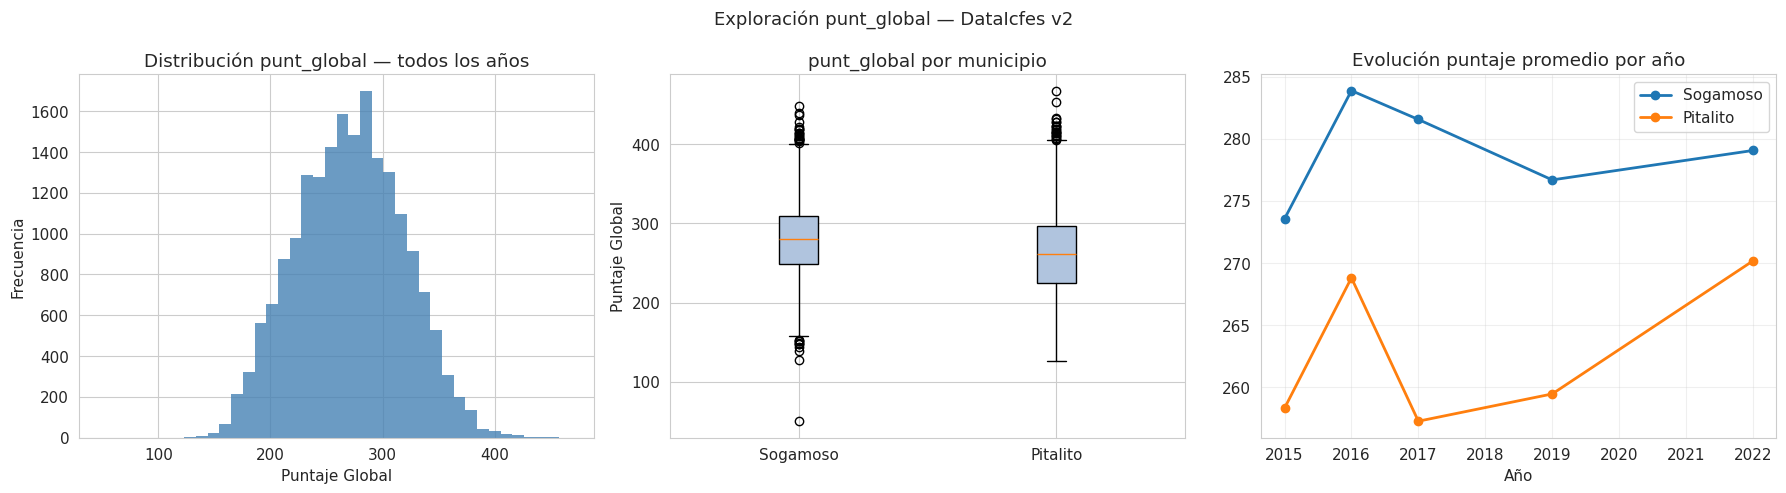


Estadísticos descriptivos por municipio:


,count,mean,std,min,25%,50%,75%,max
cole_cod_mcpio_ubicacion,,,,,,,,
Sogamoso,10049.0000,278.8983,44.0037,50.0000,249.0000,280.0000,310.0000,449.0000
Pitalito,9105.0000,262.4633,50.0811,126.0000,225.0000,261.0000,297.0000,468.0000


In [18]:
# Celda 2.2 — Distribución de punt_global y comparación entre municipios

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma global
df_raw['punt_global'] = pd.to_numeric(df_raw['punt_global'], errors='coerce')
axes[0].hist(df_raw['punt_global'].dropna(), bins=40,
             color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title('Distribución punt_global — todos los años')
axes[0].set_xlabel('Puntaje Global')
axes[0].set_ylabel('Frecuencia')

# Boxplot por municipio
datos_mun = [df_raw[df_raw['cole_cod_mcpio_ubicacion']==m]['punt_global'].dropna()
             for m in MUNICIPIOS]
axes[1].boxplot(datos_mun, labels=list(MUNICIPIOS.values()), patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue'))
axes[1].set_title('punt_global por municipio')
axes[1].set_ylabel('Puntaje Global')

# Evolución temporal
for m, nombre in MUNICIPIOS.items():
    serie = (df_raw[df_raw['cole_cod_mcpio_ubicacion']==m]
             .groupby('anio')['punt_global'].mean())
    axes[2].plot(serie.index, serie.values, marker='o', label=nombre, linewidth=2)
axes[2].set_title('Evolución puntaje promedio por año')
axes[2].set_xlabel('Año')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Exploración punt_global — DataIcfes v2', fontsize=13)
plt.tight_layout()
plt.show()

print("\nEstadísticos descriptivos por municipio:")
display(df_raw.groupby('cole_cod_mcpio_ubicacion')['punt_global']
        .describe().rename(index=MUNICIPIOS))


---
## SECCIÓN 3 — Encoding y transformación

In [19]:
# Celda 3.1 — Eliminar registros sin punt_global

df_enc = df_raw.copy()
df_enc['punt_global'] = pd.to_numeric(df_enc['punt_global'], errors='coerce')

antes = len(df_enc)
df_enc = df_enc[df_enc['punt_global'].notna()].copy()
print(f"Eliminados por punt_global nulo: {antes - len(df_enc):,}")
print(f"Registros restantes            : {len(df_enc):,}")


Eliminados por punt_global nulo: 0
Registros restantes            : 19,154


In [20]:
# Celda 3.2 — Encoding de variables categóricas
# Todos los mapeos se definen aquí para fácil revisión y ajuste

df_enc.replace('', np.nan, inplace=True)

# ── 1. Binarias Si/No ───────────────────────────────────────────────
BIN_MAP = {'Si': 1, 'S': 1, 'N': 0, 'No': 0, 'True': 1, 'False': 0}
BIN_COLS = ['fami_tieneinternet', 'fami_tienecomputador',
            'fami_tieneautomovil', 'fami_tienelavadora',
            'fami_tieneserviciotv', 'fami_tienemotocicleta',
            'fami_tienehornomicroogas', 'cole_bilingue']
for col in BIN_COLS:
    df_enc[col] = df_enc[col].astype(str).str.strip().map(BIN_MAP)

# ── 2. Estrato vivienda ─────────────────────────────────────────────
EST_MAP = {f'Estrato {i}': i for i in range(1, 7)}
EST_MAP['Sin Estrato'] = np.nan
df_enc['fami_estratovivienda'] = df_enc['fami_estratovivienda'].map(EST_MAP)

# ── 3. Educación padres (ordinal 0-7) ───────────────────────────────
EDU_MAP = {
    'Ninguno': 0,
    'Primaria incompleta': 1,
    'Primaria completa': 2,
    'Secundaria (Bachillerato) incompleta': 3,
    'Secundaria (Bachillerato) completa': 4,
    'Técnica o tecnológica incompleta': 5,
    'Técnica o tecnológica completa': 5,
    'Técnica o Tecnológica incompleta': 5,
    'Técnica o Tecnológica completa': 5,
    'Educación profesional incompleta': 6,
    'Educación profesional completa': 6,
    'Postgrado': 7,
}
for col in ['fami_educacionmadre', 'fami_educacionpadre']:
    df_enc[col] = (df_enc[col].astype(str).str.strip()
                   .str.replace('é','e').str.replace('ó','o')
                   .str.replace('é','e').str.replace('ú','u')
                   .map(EDU_MAP))

# ── 4. Personas hogar ───────────────────────────────────────────────
PER_MAP = {
    'Una': 1, 'Dos': 2, 'Tres': 3, 'Cuatro': 4, 'Cinco': 5,
    'Seis': 6, 'Siete': 7, 'Ocho': 8, 'Nueve': 9, 'Diez': 10,
    'Once': 11, 'Doce o más': 12,
    '1 a 2': 1.5, '2 a 3': 2.5, '3 a 4': 3.5,
    '4 a 5': 4.5, '5 a 6': 5.5, '6 a 7': 6.5,
    '7 a 8': 7.5, '9 o más': 9.0, 'Siete o más': 7.0,
}
df_enc['fami_personashogar'] = (df_enc['fami_personashogar']
                                 .astype(str).str.strip().map(PER_MAP)
                                 .combine_first(
    pd.to_numeric(df_enc['fami_personashogar'], errors='coerce')))

# ── 5. Cuartos hogar (ordinal 1-5) ──────────────────────────────────
CUA_MAP = {'Uno': 1, 'Dos': 2, 'Tres': 3, 'Cuatro': 4,
           'Cinco': 5, 'Cinco o más': 5}
df_enc['fami_cuartoshogar'] = (df_enc['fami_cuartoshogar']
                                .astype(str).str.strip().map(CUA_MAP))

# ── 6. Número de libros (ordinal 0-4) ───────────────────────────────
LIB_MAP = {
    '0 libros': 0, 'Ninguno': 0,
    'Entre 0 y 10 libros': 1, '0 A 10 LIBROS': 1,
    'Entre 11 y 25 libros': 2, '11 A 25 LIBROS': 2,
    'Entre 26 y 100 libros': 3, '26 A 100 LIBROS': 3,
    'Más de 100 libros': 4, 'MAS DE 100 LIBROS': 4,
}
df_enc['fami_numlibros'] = (df_enc['fami_numlibros']
                             .astype(str).str.strip()
                             .str.replace('á','a').str.replace('Á','A')
                             .map(LIB_MAP))

# ── 7. Situación económica (ordinal 0-2) ────────────────────────────
SIT_MAP = {'Peor': 0, 'Igual': 1, 'Mejor': 2}
df_enc['fami_situacioneconomica'] = (df_enc['fami_situacioneconomica']
                                      .astype(str).str.strip().map(SIT_MAP))

# ── 8. Cole naturaleza y área ───────────────────────────────────────
df_enc['cole_naturaleza']    = df_enc['cole_naturaleza'].map(
    {'OFICIAL': 1, 'NO OFICIAL': 0})
df_enc['cole_area_ubicacion'] = df_enc['cole_area_ubicacion'].map(
    {'URBANO': 1, 'RURAL': 0,
     'URBANA': 1, 'RURAL': 0})

# ── 9. Carácter colegio ─────────────────────────────────────────────
CAR_MAP = {
    'ACADÉMICO': 0, 'ACADEMICO': 0,
    'TÉCNICO/ACADÉMICO': 1, 'TECNICO/ACADEMICO': 1,
    'TÉCNICO': 2, 'TECNICO': 2,
    'NO APLICA': np.nan,
}
df_enc['cole_caracter'] = (df_enc['cole_caracter']
                            .astype(str).str.strip().map(CAR_MAP))

# ── 10. Jornada ─────────────────────────────────────────────────────
JOR_MAP = {
    'MAÑANA': 0, 'MANANA': 0,
    'TARDE': 1, 'COMPLETA': 2, 'NOCHE': 3,
    'NOCTURNA': 3, 'SABATINA': 4, 'DOMINICAL': 5,
    'UNICA': 2,
}
df_enc['cole_jornada'] = (df_enc['cole_jornada']
                           .astype(str).str.strip().map(JOR_MAP))

# ── 11. Género colegio y estudiante ─────────────────────────────────
df_enc['cole_genero']  = df_enc['cole_genero'].map(
    {'MIXTO': 0, 'FEMENINO': 1, 'MASCULINO': 2})
df_enc['estu_genero']  = df_enc['estu_genero'].map({'F': 0, 'M': 1})

# ── 12. NSE establecimiento (ordinal 1-4) ───────────────────────────
df_enc['estu_nse_establecimiento'] = pd.to_numeric(
    df_enc['estu_nse_establecimiento'], errors='coerce')

# ── 13. INSE individual (continuo) ──────────────────────────────────
df_enc['estu_inse_individual'] = pd.to_numeric(
    df_enc['estu_inse_individual'], errors='coerce')

# ── 14. Dedicación internet (ordinal 0-5) ───────────────────────────
DED_MAP = {
    'No Navega Internet': 0, 'No navega en internet': 0,
    '30 minutos o menos': 1,
    'Entre 30 y 60 minutos': 2,
    'Entre 1 y 3 horas': 3, 'Entre 1 y 2 horas': 3,
    'Más de 3 horas': 4, 'Más de 5 horas': 5,
}
df_enc['estu_dedicacioninternet'] = (df_enc['estu_dedicacioninternet']
                                      .astype(str).str.strip().map(DED_MAP))

# ── 15. Dedicación lectura diaria (ordinal 0-4) ─────────────────────
LEC_MAP = {
    '30 minutos o menos': 1,
    'Entre 1 y 2 horas': 2,
    'Entre 30 y 60 minutos': 2,
    'Más de 2 horas': 3,
    'No lee': 0,
}
df_enc['estu_dedicacionlecturadiaria'] = (
    df_enc['estu_dedicacionlecturadiaria']
    .astype(str).str.strip().map(LEC_MAP))

# ── 16. Horas semana trabaja (ordinal 0-4) ──────────────────────────
# NOTA: en el archivo 2022 el valor '0' significa 'no trabaja'
TRA_MAP = {
    '0': 0, 'No trabaja': 0,
    'Menos de 10 horas': 1,
    'Entre 11 y 20 horas': 2,
    'Entre 21 y 30 horas': 3,
    'Más de 30 horas': 4,
}
df_enc['estu_horassemanatrabaja'] = (df_enc['estu_horassemanatrabaja']
                                      .astype(str).str.strip().map(TRA_MAP))

# ── 17. estu_repite ─────────────────────────────────────────────────
# NOTA: el campo contiene número de documento en algunos registros.
# Solo los valores '0' (no repite) son confiables.
# Se mapea 0 → 0 (no repite), cualquier otro valor numérico → NaN.
df_enc['estu_repite'] = pd.to_numeric(
    df_enc['estu_repite'], errors='coerce')
df_enc['estu_repite'] = df_enc['estu_repite'].apply(
    lambda x: 0 if x == 0 else np.nan)

print("Encoding completado.")
print("\nTipos resultantes:")
display(df_enc[COLS_CARGAR[:-1]].dtypes.to_frame('dtype'))


Encoding completado.

Tipos resultantes:


,dtype
periodo,int64
cole_cod_mcpio_ubicacion,int64
cole_cod_dane_establecimiento,int64
cole_area_ubicacion,int64
cole_naturaleza,int64
cole_caracter,float64
cole_jornada,float64
cole_bilingue,float64
cole_genero,int64
fami_estratovivienda,float64


Variables con nulos:


,Nulos,Porcentaje (%)
cole_caracter,19154,100.0000
estu_dedicacionlecturadiaria,10278,53.7000
estu_dedicacioninternet,9824,51.3000
cole_jornada,9048,47.2000
estu_horassemanatrabaja,8511,44.4000
fami_tienehornomicroogas,7941,41.5000
fami_situacioneconomica,7936,41.4000
fami_tienemotocicleta,7927,41.4000
estu_repite,6277,32.8000
fami_educacionmadre,5352,27.9000


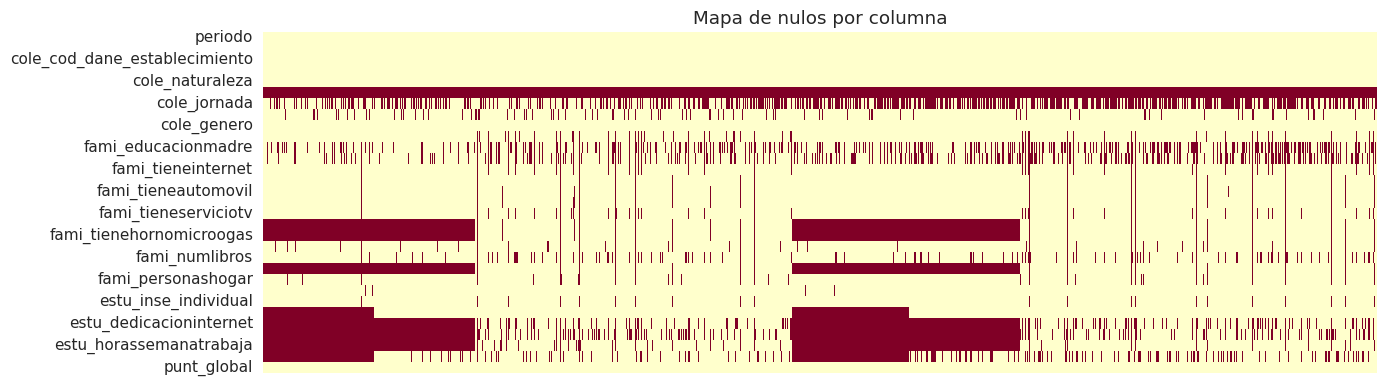

In [21]:
# Celda 3.3 — Reporte de nulos post-encoding

nulos = df_enc[COLS_CARGAR].isnull().sum()
nulos_pct = (nulos / len(df_enc) * 100).round(1)
df_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
df_nulos = df_nulos[df_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)
print("Variables con nulos:")
display(df_nulos)

# Heatmap de nulos
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(df_enc[COLS_CARGAR].isnull().T,
            cmap='YlOrRd', cbar=False, ax=ax,
            xticklabels=False)
ax.set_title('Mapa de nulos por columna')
plt.tight_layout()
plt.show()


In [22]:
# Celda 3.4 — Imputación de nulos

df_clean = df_enc.copy()

# Variables binarias del hogar: mediana por año
# (la conectividad mejora con el tiempo — no imputar con mediana global)
BIN_HOGAR = ['fami_tieneinternet', 'fami_tienecomputador',
             'fami_tieneautomovil', 'fami_tienelavadora',
             'fami_tieneserviciotv', 'fami_tienemotocicleta',
             'fami_tienehornomicroogas']
for col in BIN_HOGAR:
    n = df_clean[col].isnull().sum()
    if n > 0:
        df_clean[col] = df_clean.groupby('anio')[col].transform(
            lambda x: x.fillna(x.median()))
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        print(f"  {col:35s}: {n:,} nulos → mediana por año")

# Resto: mediana global
MEDIANA_COLS = [
    'fami_educacionmadre', 'fami_educacionpadre', 'fami_estratovivienda',
    'fami_personashogar', 'fami_cuartoshogar', 'fami_numlibros',
    'fami_situacioneconomica', 'cole_caracter', 'cole_jornada',
    'cole_genero', 'cole_bilingue', 'estu_genero',
    'estu_inse_individual', 'estu_nse_establecimiento',
    'estu_dedicacioninternet', 'estu_dedicacionlecturadiaria',
    'estu_horassemanatrabaja',
]
for col in MEDIANA_COLS:
    n = df_clean[col].isnull().sum()
    if n > 0:
        med = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(med)
        print(f"  {col:35s}: {n:,} nulos → mediana ({med:.2f})")

# estu_repite: imputar con 0 (no repite — caso más frecuente)
n = df_clean['estu_repite'].isnull().sum()
df_clean['estu_repite'] = df_clean['estu_repite'].fillna(0)
print(f"  {'estu_repite':35s}: {n:,} nulos → 0 (no repite)")

print(f"\nNulos restantes: {df_clean.isnull().sum().sum()}")
print(f"Shape final    : {df_clean.shape}")


  fami_tieneinternet                 : 638 nulos → mediana por año
  fami_tienecomputador               : 363 nulos → mediana por año
  fami_tieneautomovil                : 387 nulos → mediana por año
  fami_tienelavadora                 : 361 nulos → mediana por año
  fami_tieneserviciotv               : 660 nulos → mediana por año
  fami_tienemotocicleta              : 7,927 nulos → mediana por año
  fami_tienehornomicroogas           : 7,941 nulos → mediana por año
  fami_educacionmadre                : 5,352 nulos → mediana (3.00)
  fami_educacionpadre                : 5,209 nulos → mediana (2.00)
  fami_estratovivienda               : 848 nulos → mediana (2.00)
  fami_personashogar                 : 569 nulos → mediana (4.00)
  fami_cuartoshogar                  : 688 nulos → mediana (3.00)
  fami_numlibros                     : 1,995 nulos → mediana (2.00)
  fami_situacioneconomica            : 7,936 nulos → mediana (1.00)
  cole_caracter                      : 19,154 nulos → med

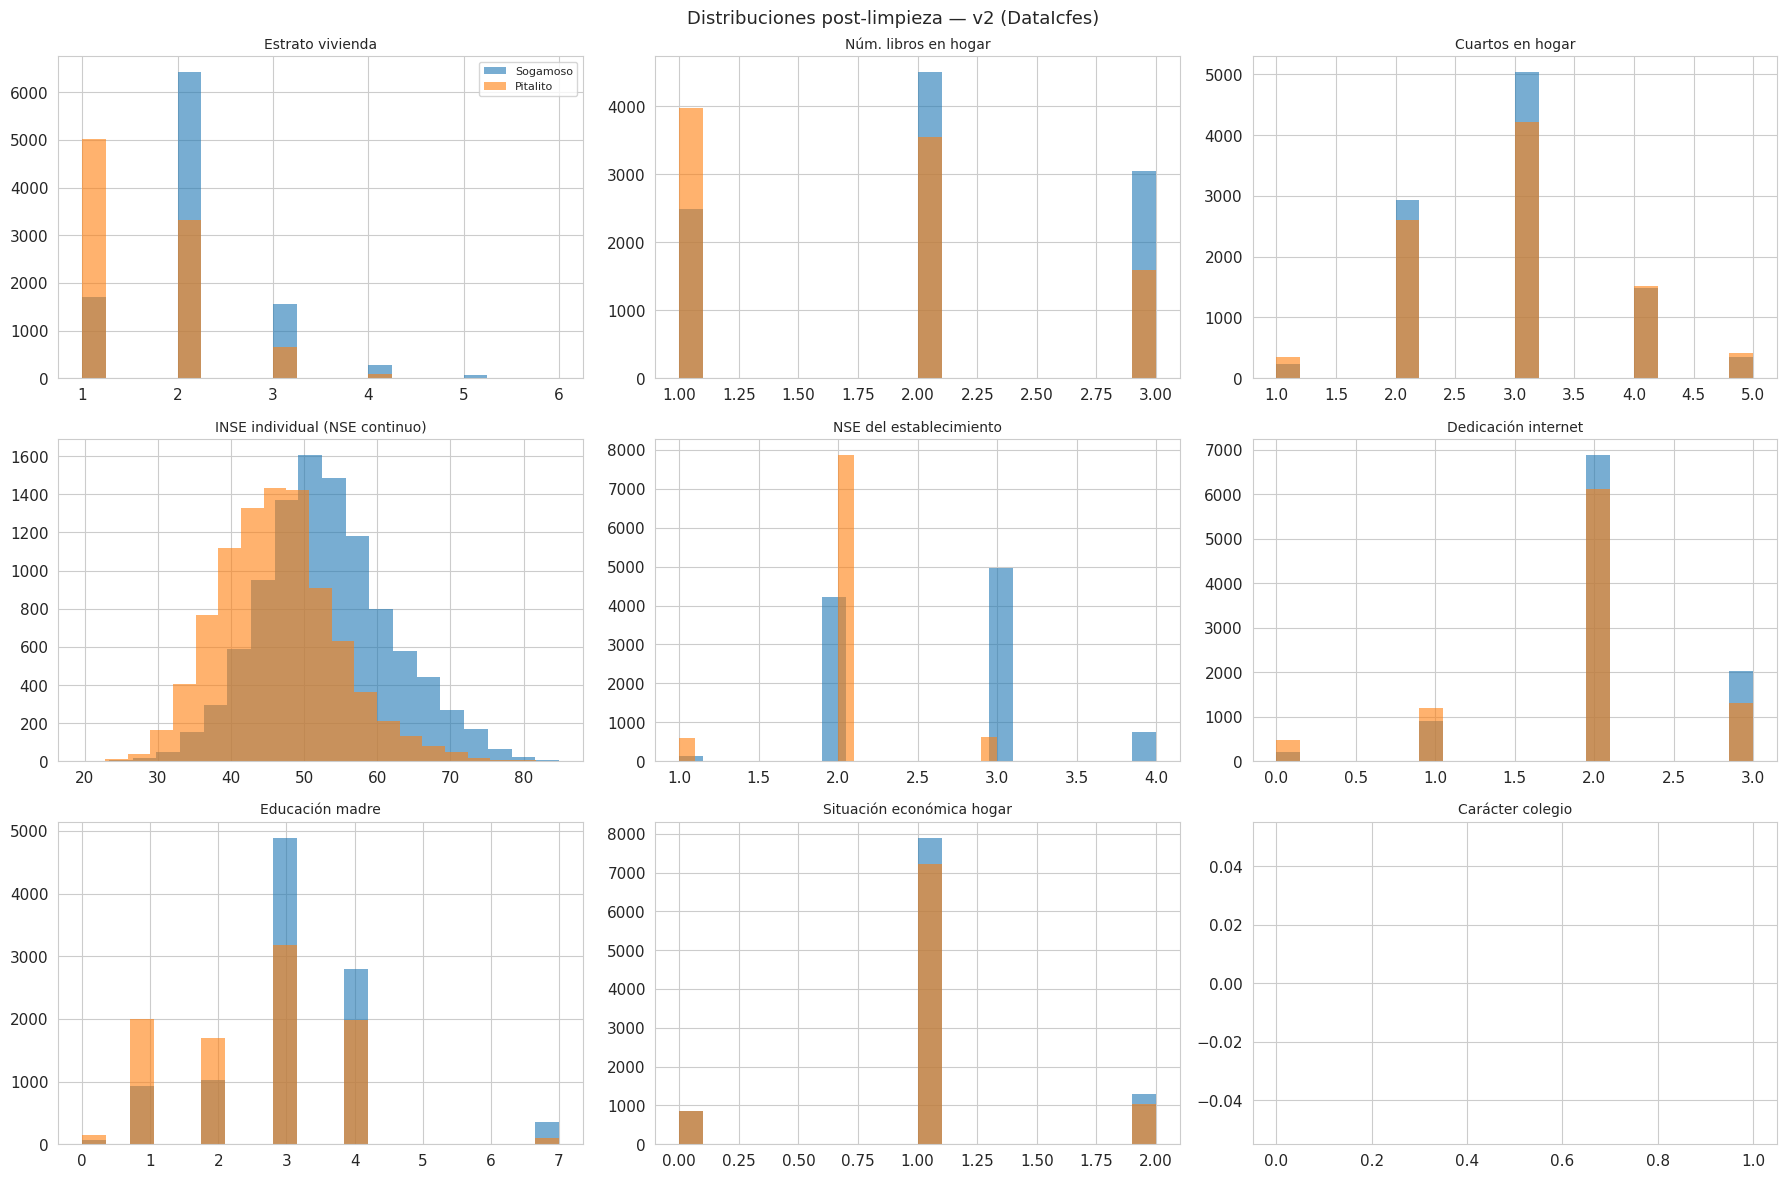

In [23]:
# Celda 3.5 — Distribuciones clave post-limpieza

fig = plt.figure(figsize=(18, 12))
PLOT_VARS = [
    ('fami_estratovivienda',       'Estrato vivienda'),
    ('fami_numlibros',             'Núm. libros en hogar'),
    ('fami_cuartoshogar',          'Cuartos en hogar'),
    ('estu_inse_individual',       'INSE individual (NSE continuo)'),
    ('estu_nse_establecimiento',   'NSE del establecimiento'),
    ('estu_dedicacioninternet',    'Dedicación internet'),
    ('fami_educacionmadre',        'Educación madre'),
    ('fami_situacioneconomica',    'Situación económica hogar'),
    ('cole_caracter',              'Carácter colegio'),
]
for i, (col, titulo) in enumerate(PLOT_VARS, 1):
    ax = fig.add_subplot(3, 3, i)
    for m, nombre in MUNICIPIOS.items():
        d = df_clean[df_clean['cole_cod_mcpio_ubicacion'] == m][col].dropna()
        ax.hist(d, bins=20, alpha=0.6, label=nombre, edgecolor='none')
    ax.set_title(titulo, fontsize=10)
    if i == 1:
        ax.legend(fontsize=8)
plt.suptitle('Distribuciones post-limpieza — v2 (DataIcfes)', fontsize=13)
plt.tight_layout()
plt.show()


---
## SECCIÓN 4 — Target y feature engineering

Cortes de terciles:
  Clase 0 (Bajo  ): [50.0 – 250.0]  6,551 estudiantes  (34.2%)
  Clase 1 (Medio ): [250.0 – 293.0]  6,353 estudiantes  (33.2%)
  Clase 2 (Alto  ): [293.0 – 468.0]  6,250 estudiantes  (32.6%)


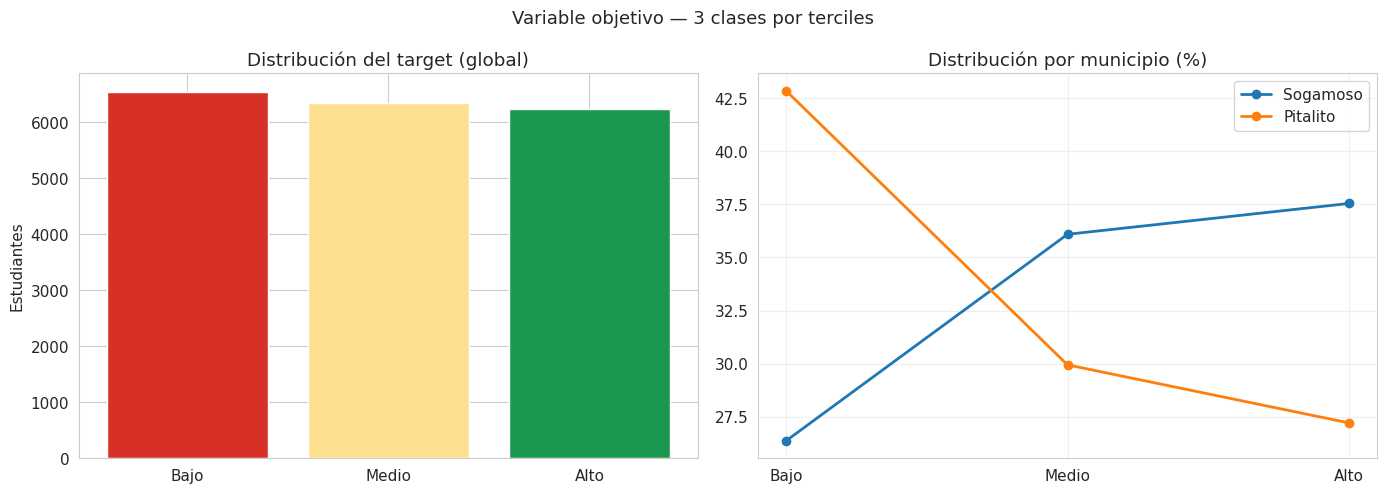

In [24]:
# Celda 4.1 — Construcción del target (3 clases por terciles)
#
# Se usan terciles (P33/P66) calculados sobre todos los datos disponibles.
# Esto garantiza ~33% de registros por clase, evitando desbalance.
# Las 3 clases son: Bajo (0), Medio (1), Alto (2).

df_clean[TARGET_COL], bins = pd.qcut(
    df_clean['punt_global'], q=3,
    labels=[0, 1, 2], retbins=True, duplicates='drop'
)
df_clean[TARGET_COL] = df_clean[TARGET_COL].astype(int)

print("Cortes de terciles:")
for i, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
    n = (df_clean[TARGET_COL] == i).sum()
    pct = n / len(df_clean) * 100
    print(f"  Clase {i} ({CLASES[i]:6s}): [{lo:.1f} – {hi:.1f}]  "
          f"{n:,} estudiantes  ({pct:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución global
dist = df_clean[TARGET_COL].value_counts().sort_index()
axes[0].bar([CLASES[i] for i in dist.index], dist.values,
            color=['#d73027', '#fee090', '#1a9850'], edgecolor='white')
axes[0].set_title('Distribución del target (global)')
axes[0].set_ylabel('Estudiantes')

# Por municipio
for m, nombre in MUNICIPIOS.items():
    dm   = df_clean[df_clean['cole_cod_mcpio_ubicacion'] == m]
    pcts = dm[TARGET_COL].value_counts(normalize=True).sort_index() * 100
    axes[1].plot(pcts.index, pcts.values, marker='o',
                 label=nombre, linewidth=2)
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(LABELS)
axes[1].set_title('Distribución por municipio (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Variable objetivo — 3 clases por terciles', fontsize=13)
plt.tight_layout()
plt.show()


In [25]:
# Celda 4.2 — Feature engineering
#
# Variables derivadas que capturan interacciones no lineales
# entre las features del hogar

# Capital educativo: suma niveles educativos de ambos padres
# Rango 0-14. Un hogar con ambos padres con posgrado = 14.
df_clean['capital_educativo'] = (df_clean['fami_educacionmadre']
                                  + df_clean['fami_educacionpadre'])

# Recursos tecnológicos: internet + computador
# Vale 0 (ninguno), 1 (solo uno), 2 (ambos)
df_clean['recursos_tech'] = (df_clean['fami_tieneinternet']
                               + df_clean['fami_tienecomputador'])

# Ventaja hogar: interacción capital educativo × tecnología
# Captura el efecto multiplicador: educación de padres amplifica
# su impacto cuando hay recursos tecnológicos disponibles
df_clean['ventaja_hogar'] = (df_clean['capital_educativo']
                               * df_clean['recursos_tech'])

# Bienes del hogar: automóvil + lavadora + TV
# Proxy de nivel socioeconómico complementario al estrato
df_clean['bienes_hogar'] = (df_clean['fami_tieneautomovil']
                              + df_clean['fami_tienelavadora']
                              + df_clean['fami_tieneserviciotv'])

# Densidad hogar: personas / cuartos (proxy de hacinamiento)
df_clean['densidad_hogar'] = (
    df_clean['fami_personashogar']
    / df_clean['fami_cuartoshogar'].replace(0, np.nan)
)
df_clean['densidad_hogar'] = df_clean['densidad_hogar'].fillna(
    df_clean['densidad_hogar'].median())

# Índice de hábitos: lectura + uso internet académico
df_clean['habitos_estudio'] = (df_clean['estu_dedicacionlecturadiaria']
                                + df_clean['estu_dedicacioninternet'])

VARS_ENG = ['capital_educativo', 'recursos_tech', 'ventaja_hogar',
            'bienes_hogar', 'densidad_hogar', 'habitos_estudio']

corr_eng = (df_clean[VARS_ENG + [TARGET_COL]]
            .corr()[TARGET_COL].drop(TARGET_COL)
            .sort_values(ascending=False))

print("Correlación variables derivadas con target:")
display(corr_eng.to_frame('r').round(4))


Correlación variables derivadas con target:


,r
ventaja_hogar,0.2409
capital_educativo,0.2291
recursos_tech,0.2017
habitos_estudio,0.1564
bienes_hogar,0.1399
densidad_hogar,-0.0606


Features candidatos: 29

Correlación con target (ordenada):


,r
estu_inse_individual,0.2969
estu_nse_establecimiento,0.2862
ventaja_hogar,0.2409
capital_educativo,0.2291
fami_numlibros,0.2239
cole_area_ubicacion,0.2190
recursos_tech,0.2017
fami_tienecomputador,0.1815
fami_tieneinternet,0.1656
habitos_estudio,0.1564


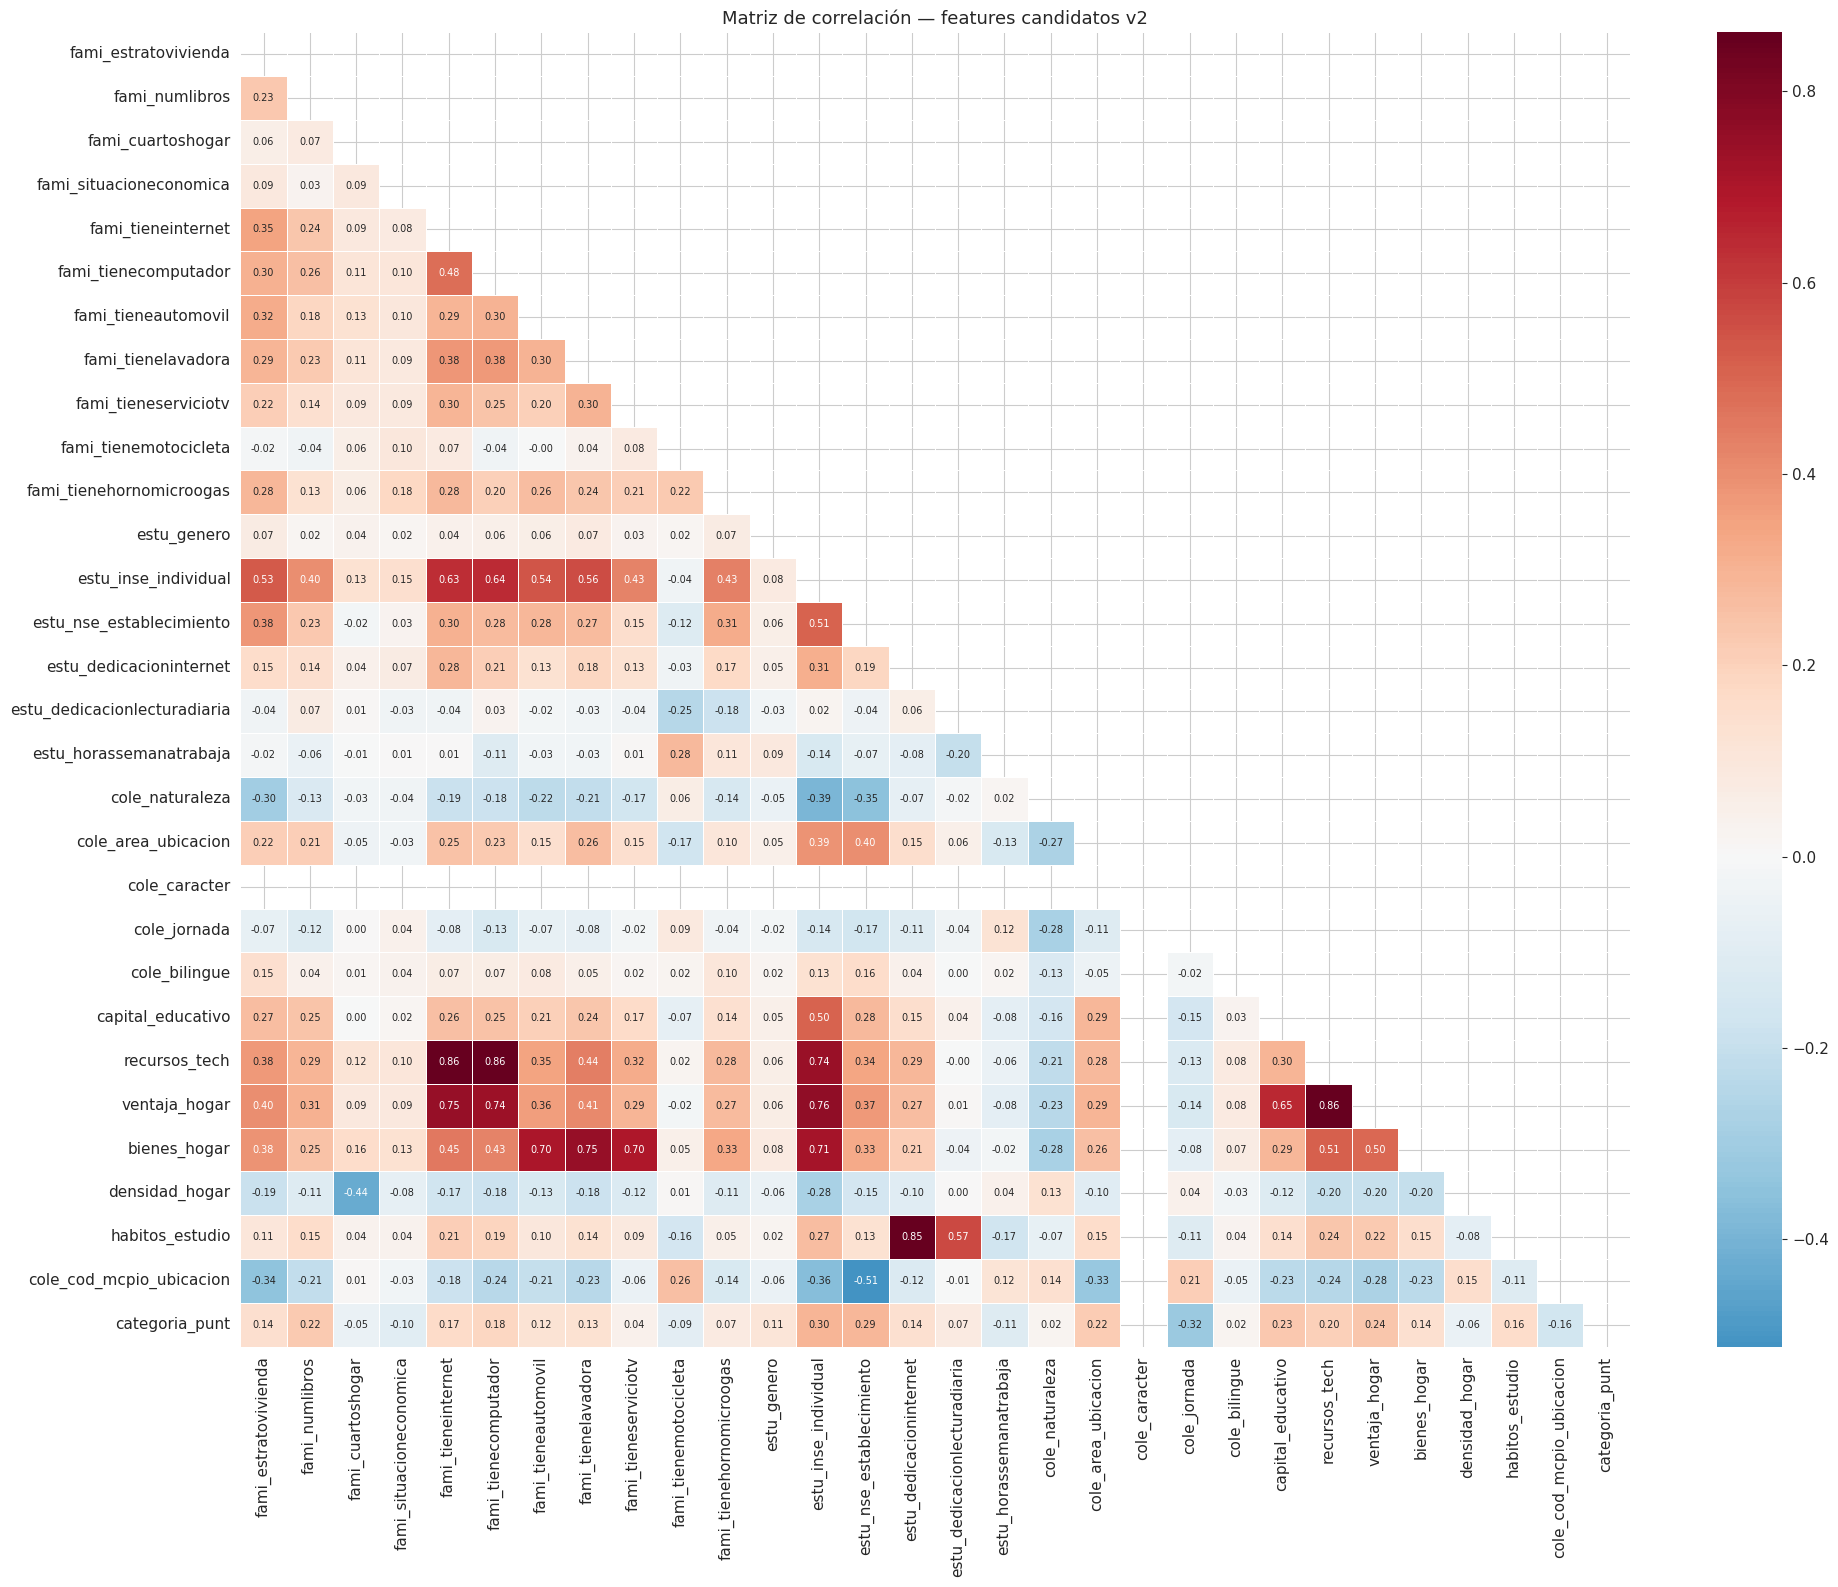

In [26]:
# Celda 4.3 — Definición de features finales y análisis de correlación

FEATURES_HOGAR = [
    'fami_estratovivienda', 'fami_numlibros', 'fami_cuartoshogar',
    'fami_situacioneconomica', 'fami_tieneinternet', 'fami_tienecomputador',
    'fami_tieneautomovil', 'fami_tienelavadora', 'fami_tieneserviciotv',
    'fami_tienemotocicleta', 'fami_tienehornomicroogas',
]
FEATURES_ESTU = [
    'estu_genero', 'estu_inse_individual', 'estu_nse_establecimiento',
    'estu_dedicacioninternet', 'estu_dedicacionlecturadiaria',
    'estu_horassemanatrabaja',
]
FEATURES_COLE = [
    'cole_naturaleza', 'cole_area_ubicacion', 'cole_caracter',
    'cole_jornada', 'cole_bilingue',
]
FEATURES_ENG  = ['capital_educativo', 'recursos_tech', 'ventaja_hogar',
                 'bienes_hogar', 'densidad_hogar', 'habitos_estudio']
FEATURES_CTRL = ['cole_cod_mcpio_ubicacion']

CANDIDATOS = (FEATURES_HOGAR + FEATURES_ESTU + FEATURES_COLE
              + FEATURES_ENG + FEATURES_CTRL)

print(f"Features candidatos: {len(CANDIDATOS)}")

# Correlación con target
corr_target = (df_clean[CANDIDATOS + [TARGET_COL]]
               .corr()[TARGET_COL].drop(TARGET_COL)
               .sort_values(ascending=False))
print("\nCorrelación con target (ordenada):")
display(corr_target.to_frame('r').round(4))

# Heatmap completo
fig, ax = plt.subplots(figsize=(20, 16))
corr_mat = df_clean[CANDIDATOS + [TARGET_COL]].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.4, annot_kws={'size': 7})
ax.set_title('Matriz de correlación — features candidatos v2', fontsize=13)
plt.tight_layout()
plt.show()


In [27]:
# Celda 4.4 — Eliminación por multicolinealidad (r > 0.85)

corr_mat = df_clean[CANDIDATOS].corr().abs()

pares_altos = []
for i, f1 in enumerate(CANDIDATOS):
    for f2 in CANDIDATOS[i+1:]:
        r = corr_mat.loc[f1, f2]
        if r > 0.85:
            pares_altos.append((f1, f2, round(r, 3)))

print("Pares con correlación > 0.85:")
for f1, f2, r in sorted(pares_altos, key=lambda x: -x[2]):
    print(f"  {f1:35s} ↔ {f2:35s}  r={r}")

# Eliminación documentada:
# Cuando dos variables son altamente colineales, se elimina la que
# es subconjunto de una variable derivada (la derivada ya la captura)
ELIMINAR = {
    'fami_tieneinternet'   : 'capturada por recursos_tech',
    'fami_tienecomputador' : 'capturada por recursos_tech',
    'fami_tieneautomovil'  : 'capturada por bienes_hogar',
    'fami_tienelavadora'   : 'capturada por bienes_hogar',
    'fami_tieneserviciotv' : 'capturada por bienes_hogar',
    'fami_educacionmadre'  : 'capturada por capital_educativo',
    'fami_educacionpadre'  : 'capturada por capital_educativo',
}
# NOTA: el script elimina solo las que realmente tengan r > 0.85
# con su variable derivada. Verificar en los pares detectados arriba
# y ajustar ELIMINAR si es necesario.

print("\nFeatures eliminadas por multicolinealidad:")
for feat, razon in ELIMINAR.items():
    if feat in CANDIDATOS:
        print(f"  ✗ {feat:35s} → {razon}")

ALL_FEATURES = [f for f in CANDIDATOS if f not in ELIMINAR]
print(f"\nFeatures finales para el modelo: {len(ALL_FEATURES)}")
for f in ALL_FEATURES:
    r = df_clean[CANDIDATOS + [TARGET_COL]].corr()[TARGET_COL].get(f, 0)
    print(f"  {f:35s}  r={r:.3f}")


Pares con correlación > 0.85:
  fami_tieneinternet                  ↔ recursos_tech                        r=0.862
  recursos_tech                       ↔ ventaja_hogar                        r=0.861
  fami_tienecomputador                ↔ recursos_tech                        r=0.859
  estu_dedicacioninternet             ↔ habitos_estudio                      r=0.854

Features eliminadas por multicolinealidad:
  ✗ fami_tieneinternet                  → capturada por recursos_tech
  ✗ fami_tienecomputador                → capturada por recursos_tech
  ✗ fami_tieneautomovil                 → capturada por bienes_hogar
  ✗ fami_tienelavadora                  → capturada por bienes_hogar
  ✗ fami_tieneserviciotv                → capturada por bienes_hogar

Features finales para el modelo: 24
  fami_estratovivienda                 r=0.145
  fami_numlibros                       r=0.224
  fami_cuartoshogar                    r=-0.052
  fami_situacioneconomica              r=-0.095
  fami_tiene

---
## SECCIÓN 5 — Preparación para modelos

In [28]:
# Celda 5.1 — Split temporal train/test

mask_train = df_clean['SPLIT'] == 'train'
mask_test  = df_clean['SPLIT'] == 'test'

print(f"Features del modelo: {len(ALL_FEATURES)}")
print(f"Train ({ANIOS_TRAIN}): {mask_train.sum():,} registros")
print(f"Test  ({ANIO_TEST})       : {mask_test.sum():,} registros")

print("\nDistribución clases — Train:")
for cls in [0, 1, 2]:
    n = (df_clean.loc[mask_train, TARGET_COL] == cls).sum()
    print(f"  {CLASES[cls]:6s}: {n:,}  ({n/mask_train.sum()*100:.1f}%)")

print("\nDistribución clases — Test:")
for cls in [0, 1, 2]:
    n = (df_clean.loc[mask_test, TARGET_COL] == cls).sum()
    print(f"  {CLASES[cls]:6s}: {n:,}  ({n/mask_test.sum()*100:.1f}%)")


Features del modelo: 24
Train ([2015, 2016, 2017, 2019]): 15,364 registros
Test  (2022)       : 3,790 registros

Distribución clases — Train:
  Bajo  : 5,353  (34.8%)
  Medio : 5,166  (33.6%)
  Alto  : 4,845  (31.5%)

Distribución clases — Test:
  Bajo  : 1,198  (31.6%)
  Medio : 1,187  (31.3%)
  Alto  : 1,405  (37.1%)


In [29]:
# Celda 5.2 — Normalización (StandardScaler)
# Fit SOLO en train — sin data leakage del test

NO_ESCALAR = {
    'cole_naturaleza', 'cole_area_ubicacion', 'cole_bilingue',
    'estu_genero', 'cole_cod_mcpio_ubicacion',
    'recursos_tech', 'bienes_hogar',
}
FEATURES_ESCALAR = [f for f in ALL_FEATURES if f not in NO_ESCALAR]

df_model = df_clean[ALL_FEATURES + [TARGET_COL, 'SPLIT']].copy()
scaler   = StandardScaler()

df_model.loc[mask_train, FEATURES_ESCALAR] = scaler.fit_transform(
    df_model.loc[mask_train, FEATURES_ESCALAR])
df_model.loc[mask_test,  FEATURES_ESCALAR] = scaler.transform(
    df_model.loc[mask_test,  FEATURES_ESCALAR])

X_train = df_model.loc[mask_train, ALL_FEATURES].values
y_train = df_model.loc[mask_train, TARGET_COL].values
X_test  = df_model.loc[mask_test,  ALL_FEATURES].values
y_test  = df_model.loc[mask_test,  TARGET_COL].values

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print("\nX_test/y_test RESERVADOS — no usar hasta Sección 6.")


X_train: (15364, 24)
X_test : (3790, 24)

X_test/y_test RESERVADOS — no usar hasta Sección 6.


In [30]:
# Celda 5.3 — Validation set para early stopping
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)
print(f"Train reducido : {X_tr.shape[0]:,}")
print(f"Validation     : {X_val.shape[0]:,}")
print(f"Test (intacto) : {X_test.shape[0]:,}")

Train reducido : 13,059
Validation     : 2,305
Test (intacto) : 3,790


---
## SECCIÓN 6 — Modelos supervisados

In [31]:
# Celda 6.0 — Utilidades compartidas

resultados = []

def acc_adyacente(y_true, y_pred):
    """Accuracy con tolerancia de 1 nivel (métrica ordinal).
    Penaliza igual confundir Bajo↔Medio que Bajo↔Alto con
    el accuracy estándar. Esta métrica es más justa para
    clases ordinales: un error de 1 nivel es menos grave
    que un error de 2 niveles."""
    return (np.abs(np.array(y_true) - np.array(y_pred)) <= 1).mean()

def registrar(nombre, y_pred):
    resultados.append({
        'Modelo'        : nombre,
        'Accuracy'      : accuracy_score(y_test, y_pred),
        'F1 macro'      : f1_score(y_test, y_pred, average='macro'),
        'F1 weighted'   : f1_score(y_test, y_pred, average='weighted'),
        'Acc. Adyacente': acc_adyacente(y_test, y_pred),
    })

def plot_cm(ax, y_pred, titulo, cmap='Blues'):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(
        ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(titulo)

print("Utilidades listas.")


Utilidades listas.



=== RF base ===
  Accuracy: 0.4997  F1 macro: 0.4949  Acc.Adyacente: 0.8984
              precision    recall  f1-score   support

        Bajo       0.59      0.55      0.57      1198
       Medio       0.36      0.35      0.35      1187
        Alto       0.54      0.58      0.56      1405

    accuracy                           0.50      3790
   macro avg       0.50      0.49      0.49      3790
weighted avg       0.50      0.50      0.50      3790


=== RF tuning ===
  Accuracy: 0.5145  F1 macro: 0.5015  Acc.Adyacente: 0.8987
              precision    recall  f1-score   support

        Bajo       0.61      0.52      0.56      1198
       Medio       0.37      0.32      0.34      1187
        Alto       0.54      0.68      0.60      1405

    accuracy                           0.51      3790
   macro avg       0.51      0.50      0.50      3790
weighted avg       0.51      0.51      0.51      3790



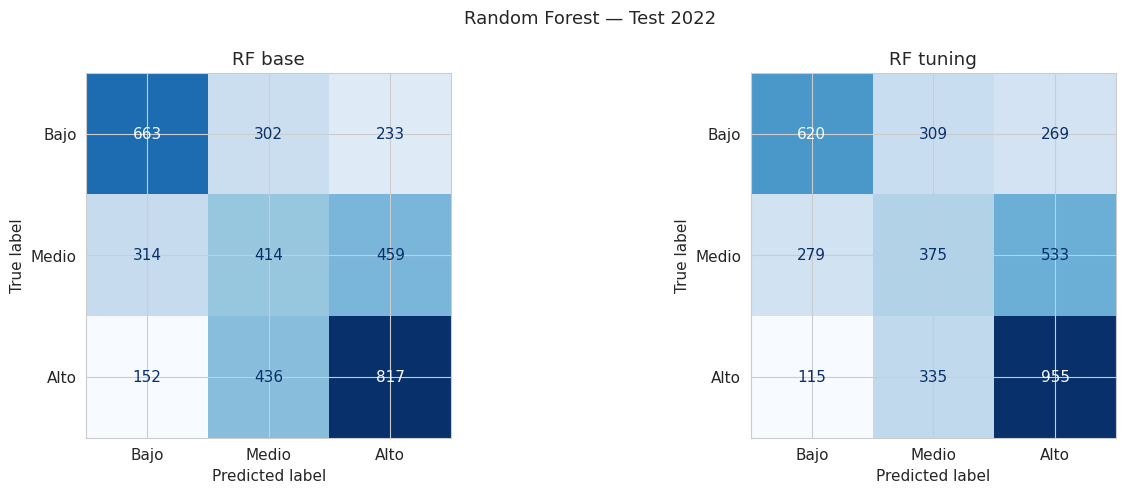

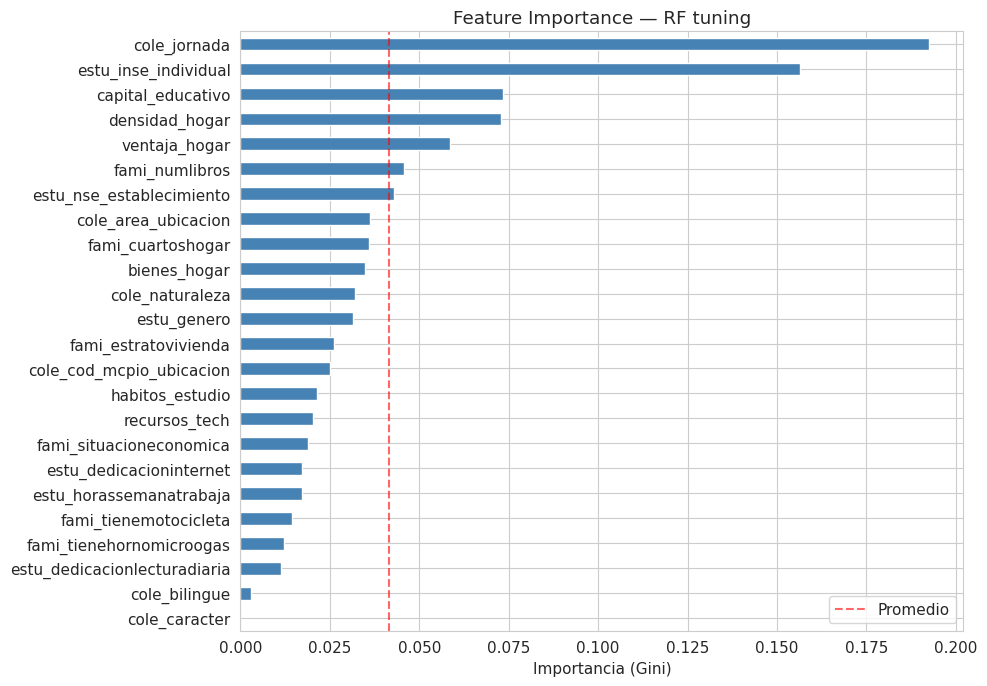

In [32]:
# Celda 6.1 — Random Forest Classifier

RF_CONFIGS = [
    ('RF base',
     dict(n_estimators=200, class_weight='balanced',
          random_state=42, n_jobs=-1)),
    ('RF tuning',
     dict(n_estimators=500, max_depth=20, min_samples_leaf=5,
          class_weight='balanced', random_state=42, n_jobs=-1)),
]

rf_preds  = {}
rf_models = {}

for nombre, params in RF_CONFIGS:
    m = RandomForestClassifier(**params)
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    rf_preds[nombre]  = y_pred
    rf_models[nombre] = m
    registrar(nombre, y_pred)
    print(f"\n=== {nombre} ===")
    print(f"  Accuracy: {accuracy_score(y_test,y_pred):.4f}  "
          f"F1 macro: {f1_score(y_test,y_pred,average='macro'):.4f}  "
          f"Acc.Adyacente: {acc_adyacente(y_test,y_pred):.4f}")
    print(classification_report(y_test, y_pred, target_names=LABELS))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (nombre, y_pred) in zip(axes, rf_preds.items()):
    plot_cm(ax, y_pred, nombre, 'Blues')
plt.suptitle('Random Forest — Test 2022', fontsize=13)
plt.tight_layout(); plt.show()

# Feature importance del mejor RF
mejor_rf = max(rf_models, key=lambda k:
    f1_score(y_test, rf_preds[k], average='macro'))
imp = pd.Series(rf_models[mejor_rf].feature_importances_,
                index=ALL_FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(10, 7))
imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.axvline(imp.mean(), color='red', linestyle='--',
           alpha=0.6, label='Promedio')
ax.set_title(f'Feature Importance — {mejor_rf}')
ax.set_xlabel('Importancia (Gini)')
ax.legend(); plt.tight_layout(); plt.show()


In [36]:
XGB_CONFIGS = [
    ('XGBoost base',
     dict(n_estimators=200, learning_rate=0.1, max_depth=6,
          random_state=42, eval_metric='mlogloss', verbosity=0)),
    ('XGBoost tuning',
     dict(n_estimators=500, learning_rate=0.05, max_depth=8,
          subsample=0.8, colsample_bytree=0.8,
          early_stopping_rounds=50,        # ← el fix
          random_state=42, eval_metric='mlogloss', verbosity=0)),
]

xgb_preds = {}

for nombre, params in XGB_CONFIGS:
    m = XGBClassifier(**params)
    usa_early = 'early_stopping_rounds' in params
    if usa_early:
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        print(f"  Árboles usados: {m.best_iteration}")
    else:
        m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    xgb_preds[nombre] = y_pred
    registrar(nombre, y_pred)
    print(f"\n=== {nombre} ===")
    print(f"  Accuracy: {accuracy_score(y_test,y_pred):.4f}  "
          f"F1 macro: {f1_score(y_test,y_pred,average='macro'):.4f}  "
          f"Acc.Adyacente: {acc_adyacente(y_test,y_pred):.4f}")
    print(classification_report(y_test, y_pred, target_names=LABELS))


=== XGBoost base ===
  Accuracy: 0.5090  F1 macro: 0.5028  Acc.Adyacente: 0.9050
              precision    recall  f1-score   support

        Bajo       0.59      0.56      0.57      1198
       Medio       0.36      0.35      0.36      1187
        Alto       0.56      0.60      0.58      1405

    accuracy                           0.51      3790
   macro avg       0.50      0.50      0.50      3790
weighted avg       0.51      0.51      0.51      3790

  Árboles usados: 91

=== XGBoost tuning ===
  Accuracy: 0.5150  F1 macro: 0.5069  Acc.Adyacente: 0.9069
              precision    recall  f1-score   support

        Bajo       0.60      0.55      0.57      1198
       Medio       0.37      0.34      0.35      1187
        Alto       0.56      0.63      0.59      1405

    accuracy                           0.52      3790
   macro avg       0.51      0.51      0.51      3790
weighted avg       0.51      0.52      0.51      3790



In [42]:
import lightgbm as lgb

In [44]:
# Celda 6.3 tuning — LightGBM con mejores parámetros encontrados
lgbm_best = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=50,
    min_child_samples=10,
    subsample=0.9,
    subsample_freq=1,
    class_weight='balanced',
    random_state=42,
    verbosity=-1
)
lgbm_best.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])

y_pred_best = lgbm_best.predict(X_test)
registrar('LightGBM best', y_pred_best)

print(f"Árboles usados : {lgbm_best.best_iteration_}")
print(f"Accuracy       : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"F1 macro       : {f1_score(y_test, y_pred_best, average='macro'):.4f}")
print(f"Acc. Adyacente : {acc_adyacente(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best, target_names=LABELS))

Árboles usados : 102
Accuracy       : 0.5208
F1 macro       : 0.5103
Acc. Adyacente : 0.9066
              precision    recall  f1-score   support

        Bajo       0.61      0.54      0.58      1198
       Medio       0.37      0.33      0.35      1187
        Alto       0.56      0.66      0.61      1405

    accuracy                           0.52      3790
   macro avg       0.51      0.51      0.51      3790
weighted avg       0.52      0.52      0.52      3790

